## Face Mask Detection with Tensorflow

---



應用情境:
  過去在疫情期間口罩成為人人都必備的東西，進出任何場所都需要配戴口罩。即使現在疫情趨緩很多場合還是需要戴口罩才能進出，未來也不保證不會有新的疫情產生。

  因此在AI普及的時代，可透過人工智慧來協助偵測人類是否有配戴口罩，減少接觸的機會。

資料集介紹:https://www.kaggle.com/datasets/ashishjangra27/face-mask-12k-images-dataset/data

此資料集用於影像的口罩偵測分類。

資料集由近12K張影像組成，大小近328.92MB。

所有戴口罩的圖像均從Google搜尋，所有無口罩的圖像均由 Jessica Li 創建的 CelebFace 資料集進行預處理（ https://www.kaggle.com/jessicali9530 ）。

### Loading Necessary Imports

In [6]:
import os
import random
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd
import tensorflow as tf


import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (12, 8)
from  IPython import display
import shutil


print("Version: ", tf.__version__)
print("GPU is", "available" if tf.config.list_physical_devices('GPU') else "NOT AVAILABLE")

Version:  2.13.0
GPU is NOT AVAILABLE


### Downloading Dataset下載資料集

In [7]:
# installing kaggle and uploading api key to download dataset directly in colab 直接從kaggle下載
!pip install -q kaggle
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"elainedu10","key":"c5df4609e823cdb792abe635a26bdfd1"}'}

In [8]:
# making a directory named kaggle and save api key json file there
! mkdir ~/.kaggle
! cp kaggle.json ~/.kaggle

In [9]:
# changing permisssion of the json file
! chmod 600 ~/.kaggle/kaggle.json

In [10]:
# verfiying if I am able to access kaggle
! kaggle datasets list

ref                                                         title                                             size  lastUpdated          downloadCount  voteCount  usabilityRating  
----------------------------------------------------------  -----------------------------------------------  -----  -------------------  -------------  ---------  ---------------  
iamsouravbanerjee/customer-shopping-trends-dataset          Customer Shopping Trends Dataset                 146KB  2023-10-05 06:45:37           8918        203  1.0              
nelgiriyewithana/top-spotify-songs-2023                     Most Streamed Spotify Songs 2023                  47KB  2023-08-26 11:04:57          37648       1094  1.0              
bkcoban/customer-transactions                               Customer Transactions                              1MB  2023-10-15 17:59:17           1010         24  1.0              
nelgiriyewithana/billionaires-statistics-dataset            Billionaires Statistics Dataset (20

In [11]:
# downloadig the particular dataset using the api command from the datset page下載資料集
!kaggle datasets download -d ashishjangra27/face-mask-12k-images-dataset

 97% 319M/330M [00:02<00:00, 98.4MB/s]
100% 330M/330M [00:02<00:00, 124MB/s] 


In [12]:
# unzipping the data解壓縮檔案
import zipfile
zip_ref = zipfile.ZipFile('face-mask-12k-images-dataset.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [13]:
#掛載至雲端硬碟
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Configurations

In [14]:
PATH = os.getcwd() #返回當前工作目錄
DATA_PATH = PATH + '/Face Mask Dataset'

LR = 0.001
BATCH_SIZE = 16
EPOCHS = 32
TARGET_SIZE = (256,256)
NUM_CLASSES = 2


### Utility Functions

In [15]:
# function to count parameters of a model計算模型參數

def count_params(model):
    non_trainable_params = np.sum([np.prod(v.get_shape().as_list())
                                    for v in model.non_trainable_weights])
    trainable_params = np.sum([np.prod(v.get_shape().as_list())
                                    for v in model.trainable_weights])
    print(non_trainable_params,trainable_params)
    return {'non_trainable_params': non_trainable_params,'trainable_params': trainable_params}


In [16]:
# function to save figures儲存圖表

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    os.chdir(PATH)
    IMAGES_PATH = PATH +'/images'

    if os.path.isdir(IMAGES_PATH) is False:
        os.mkdir('images')
        IMAGES_PATH = PATH + '/images'
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)

    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)
    return

In [17]:
# function for ploting training訓練圖

def plot_training(history,name):
    hist = pd.DataFrame()
    hist["Train Loss"]=history.history['loss']
    hist["Validation Loss"]=history.history['val_loss']
    hist["Train Accuracy"]=history.history['accuracy']
    hist["Validation Accuracy"]=history.history['val_accuracy']

    fig, axarr=plt.subplots(nrows=2, ncols=1 ,figsize=(8,6))
    axarr[0].set_title("History of Loss in Train and Validation Datasets")
    hist[["Train Loss", "Validation Loss"]].plot(ax=axarr[0])
    axarr[1].set_title("History of Accuracy in Train and Validation Datasets")
    hist[["Train Accuracy", "Validation Accuracy"]].plot(ax=axarr[1])
    save_fig(name)
    plt.show()

In [18]:
# ploting the outputs using confusion matrix混淆矩陣繪製輸出

def plot_confusion(y_test,y_predict,name):
	cm = confusion_matrix(y_test, y_predict)
	class_names=[0,1,2,3,4,5,6,7,8,9]
	fig, ax = plt.subplots(figsize=(6,6))
	tick_marks = np.arange(len(class_names))
	plt.xticks(tick_marks, class_names)
	plt.yticks(tick_marks, class_names)
	sns.heatmap(pd.DataFrame(cm), annot=True, cmap="Purples" ,fmt='g')
	ax.xaxis.set_label_position("top")
	plt.tight_layout()
	plt.title('Confusion Matrix', y=1.1)
	plt.ylabel('Actual label')
	plt.xlabel('Predicted label')
	save_fig(name)
	plt.show()
	return

Saving figure train_imgs


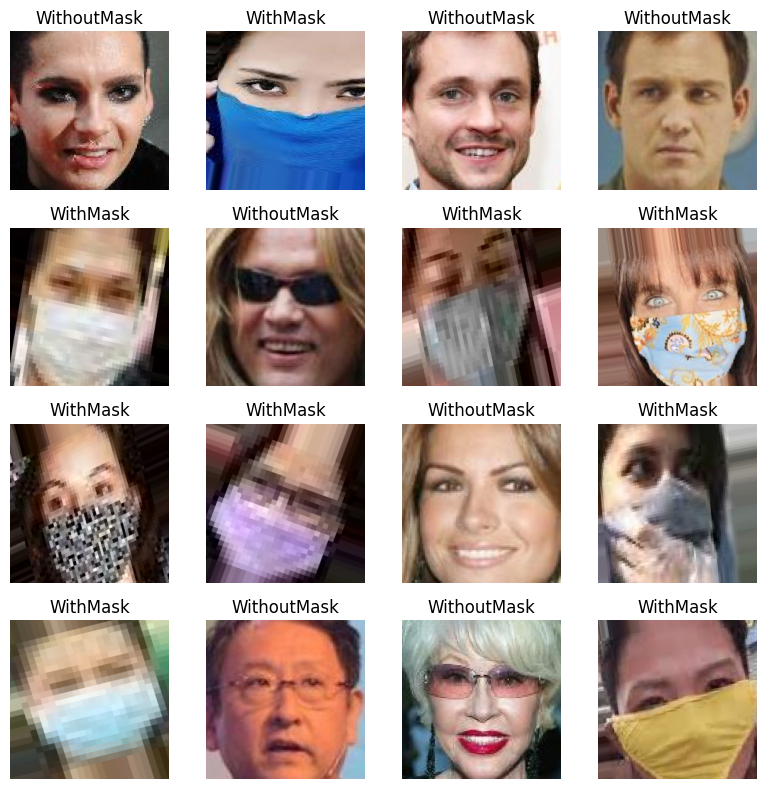

In [19]:
# ploting images from train dir從Training目錄繪製影像

def plot_images(PATH):
  images = []
  for folder in os.listdir(PATH):
    for image in os.listdir(PATH + '/' + folder):
      images.append((os.path.join(PATH, folder, image), folder))

  plt.figure(1, figsize=(8, 8))

  for i in range(16):
    i += 1

    random_img = random.choice(images)
    imgs = plt.imread(random_img[0])
    plt.subplot(4, 4,i)
    plt.axis('off')
    plt.title(random_img[1])
    plt.imshow(imgs)
  save_fig('train_imgs')
  plt.show()


plot_images(DATA_PATH + '/Train')

Saving figure count_plt


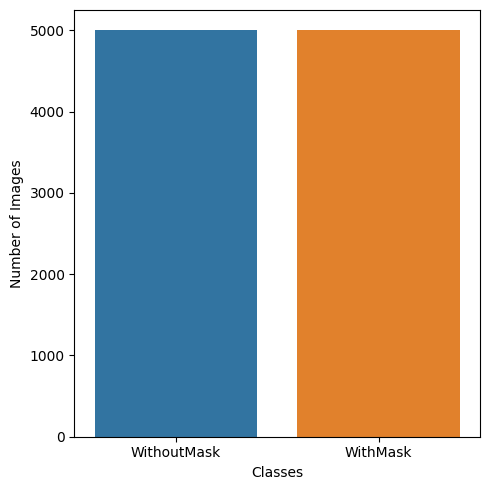

In [20]:
# image distribution影像分佈

def count_plot(path):
  class_counts = {}

  for subdir in os.listdir(path):
      subdir_path = os.path.join(path, subdir)
      class_counts[subdir] = len(os.listdir(subdir_path))

  fig = plt.figure(figsize=(5, 5))

  sns.barplot(x=list(class_counts.keys()), y =list(class_counts.values()),data=None)
  plt.xlabel('Classes')
  plt.ylabel('Number of Images')
  save_fig('count_plt')
  plt.show()


count_plot(DATA_PATH +'/Train')

Saving figure pie_chart


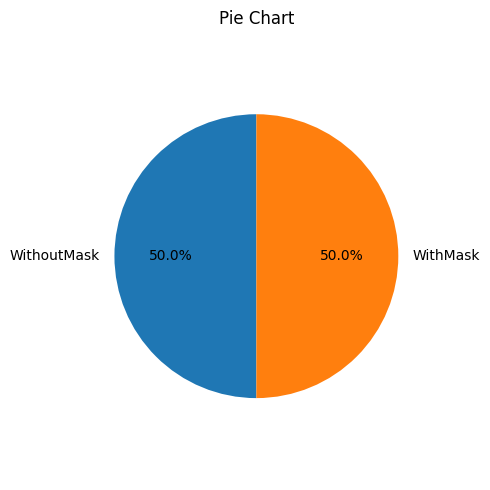

In [21]:
# pie chart to view image distribution visually 圓餅圖

def pie_chart(path):
        os.chdir(path)
        list_dir = []
        list_dir = os.listdir(os.getcwd())
        count = {}
        for dir in list_dir:
                file = os.listdir(os.getcwd()+'/' +dir)
                count[dir] = len(file)

        fig = plt.figure(figsize=(5, 5))

        plt.pie(list(count.values()), labels=list(count.keys()), autopct='%1.1f%%',
                startangle=90.0,radius=15.0)

        plt.axis('equal')
        plt.title("Pie Chart")
        save_fig('pie_chart')
        plt.show()
        return

pie_chart(DATA_PATH + '/Train')
# Validation Data also has almost same distriibution but test data is uniform

### Create Batches

In [22]:
# function to create test, train and valid batches

from keras.preprocessing.image import ImageDataGenerator

def create_batches(path):
    train_path = path + '/Train'
    test_path = path + '/Test'
    valid_path = path + '/Validation'

    #  Create a data augmentor影像增強
    data_augmentor = ImageDataGenerator(
                                samplewise_center=True,
                                rescale=1./255,
                                shear_range=0.2,
                                zoom_range = 0.2,
                                samplewise_std_normalization=True)



    train_batches = data_augmentor.flow_from_directory(
                                                directory=train_path,
                                                target_size=TARGET_SIZE,
                                                batch_size=BATCH_SIZE,
                                                class_mode='binary')


    test_batches = data_augmentor.flow_from_directory(
                                                directory=test_path,
                                                target_size=TARGET_SIZE,
                                                shuffle=False,
                                                batch_size=BATCH_SIZE,
                                                class_mode='binary')

    valid_batches = data_augmentor.flow_from_directory(
                                                        directory=valid_path,
                                                        target_size=TARGET_SIZE,
                                                        batch_size=BATCH_SIZE,
                                                        class_mode='binary')

    return (train_batches,test_batches,valid_batches)


PATH = DATA_PATH
train_batches,test_batches,valid_batches = create_batches(PATH)

Found 10000 images belonging to 2 classes.
Found 992 images belonging to 2 classes.
Found 800 images belonging to 2 classes.


### Model Creation建造模型

In [23]:
# function for model creation

from keras.layers import Conv2D, MaxPooling2D, Dropout, Dense, Flatten
from keras.models import Sequential
def create_model():

    model = Sequential()
    #第1層卷積 feature map卷积核的数目16個 kernel卷積核大小3*3
    model.add(Conv2D(16, (3, 3), activation = "relu",input_shape=(256,256,3)))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.2))
    #第2層卷積
    model.add(Conv2D(32, (3, 3), activation = "relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.2))
    model.add(Conv2D(32, (3, 3), activation = "relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.2))
    model.add(Conv2D(64, (3, 3), activation = "relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.2))
    model.add(Flatten()) #推平成一行
    model.add(Dense(128, activation = "relu")) #Dense全連接層 128個神經元
    model.add(Dropout(0.2))
    model.add(Dense(1, activation = "sigmoid"))

    model.summary()

    return model

In [24]:
model = create_model()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 254, 254, 16)      448       
                                                                 
 max_pooling2d (MaxPooling2  (None, 127, 127, 16)      0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 127, 127, 16)      0         
                                                                 
 conv2d_1 (Conv2D)           (None, 125, 125, 32)      4640      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 62, 62, 32)        0         
 g2D)                                                            
                                                                 
 dropout_1 (Dropout)         (None, 62, 62, 32)        0

### Model Training訓練模型

In [25]:
def train_and_evaluate_model(model):

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                  loss=tf.losses.BinaryCrossentropy(),
                  metrics=[tf.metrics.BinaryAccuracy(name='accuracy')])

    history = model.fit(train_batches,
                        epochs= EPOCHS,
                        batch_size=BATCH_SIZE,
                        validation_data=valid_batches,
                        callbacks=[
                                  tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3,mode='min')
                        ], verbose =1)
    return (history, model)


In [26]:
history, trained_model = train_and_evaluate_model(model)

Epoch 1/32
625/625 [==============================] - 852s 1s/step - loss: 0.1955 - accuracy: 0.9205 - val_loss: 0.1671 - val_accuracy: 0.9600
Epoch 2/32
625/625 [==============================] - 855s 1s/step - loss: 0.0838 - accuracy: 0.9704 - val_loss: 0.0994 - val_accuracy: 0.9775
Epoch 3/32
625/625 [==============================] - 858s 1s/step - loss: 0.0617 - accuracy: 0.9781 - val_loss: 0.0806 - val_accuracy: 0.9800
Epoch 4/32
625/625 [==============================] - 865s 1s/step - loss: 0.0433 - accuracy: 0.9842 - val_loss: 0.0527 - val_accuracy: 0.9850
Epoch 5/32
625/625 [==============================] - 838s 1s/step - loss: 0.0388 - accuracy: 0.9854 - val_loss: 0.0380 - val_accuracy: 0.9875
Epoch 6/32
625/625 [==============================] - 838s 1s/step - loss: 0.0314 - accuracy: 0.9894 - val_loss: 0.0505 - val_accuracy: 0.9812
Epoch 7/32
625/625 [==============================] - 834s 1s/step - loss: 0.0252 - accuracy: 0.9918 - val_loss: 0.0410 - val_accuracy: 0.9900

##展示訓練成果

Saving figure base_conv_train


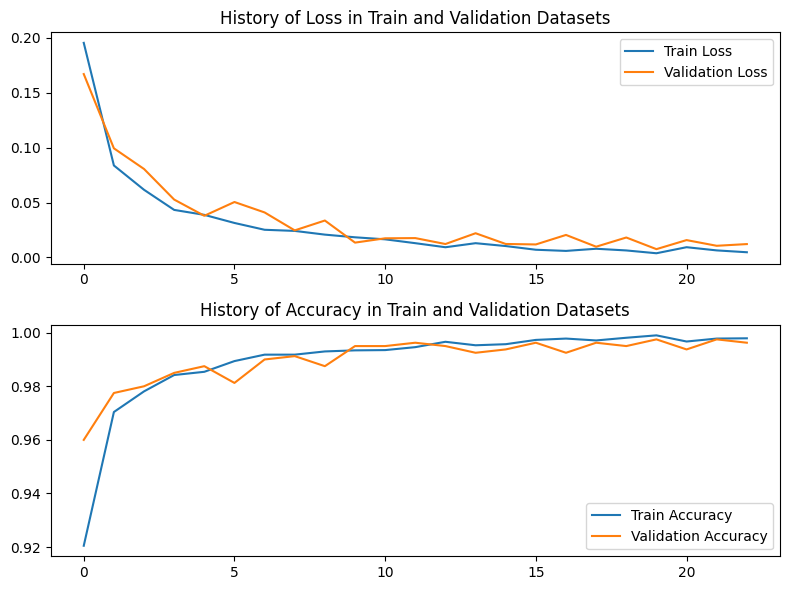

In [27]:
plot_training(history, "base_conv_train")

### Model Testing

62/62 [==============================] - 35s 563ms/step
Saving figure base_conv


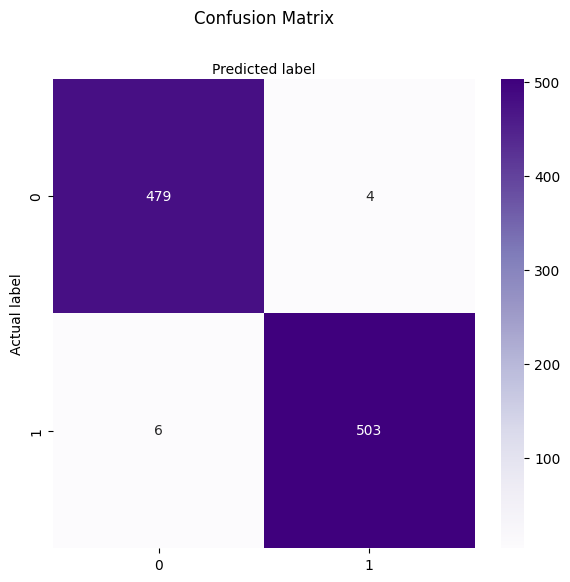

In [28]:
test_labels = test_batches.classes
predictions = trained_model.predict(test_batches)
y_pred= np.round(predictions)
plot_confusion(test_labels,y_pred, 'base_conv')

### Saving Model

In [29]:
# saving model
M_PATH = PATH + '/models'
model.save(M_PATH + "/base_model.h5")

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [30]:
from keras.models import load_model
def mload_model():
    model = tf.keras.models.load_model('/content/Face Mask Dataset/models/base_model.h5', compile=False)
    return model

In [31]:

model = mload_model()

### Making Predictions

### On Image

1/1 [==============================] - 0s 39ms/step
WITH MASK
Saving figure mask_detection2


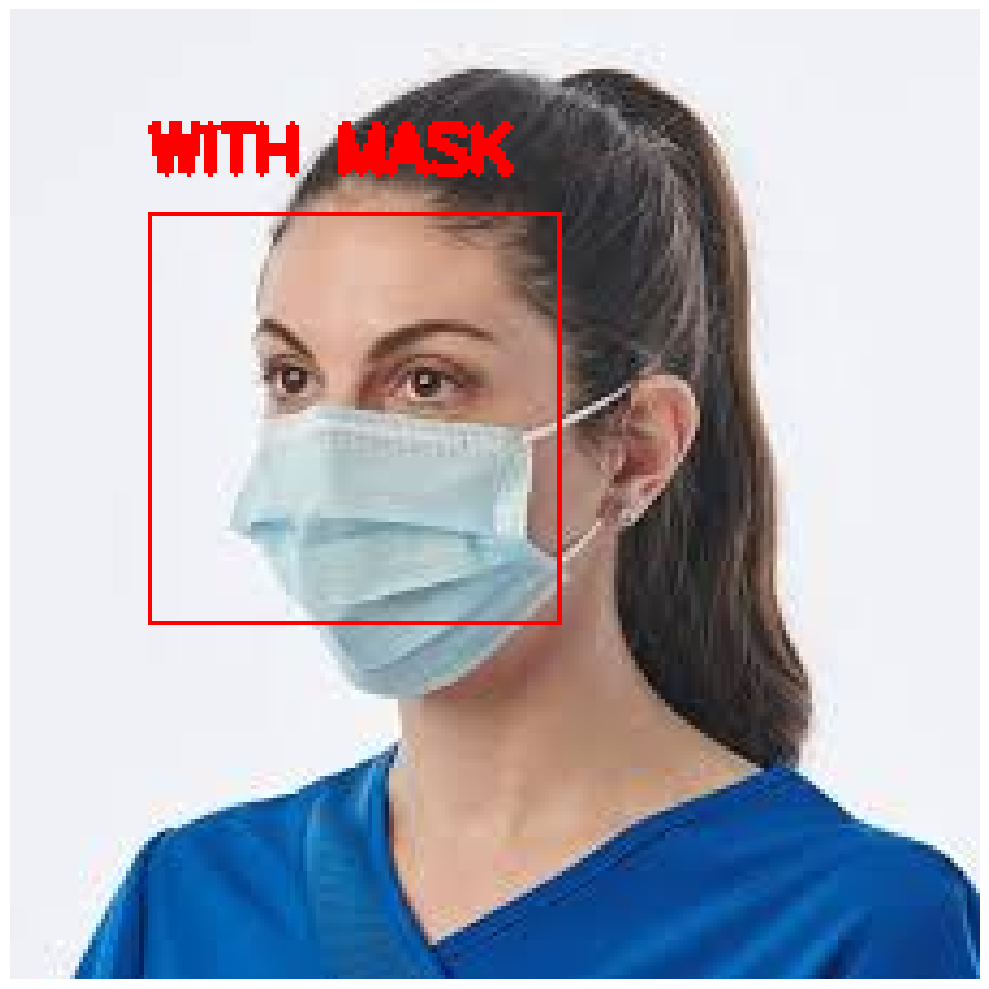

In [41]:
from matplotlib.layout_engine import nullcontext
from tensorflow.python.framework.ops import NullContextmanager
import cv2
mask_label = {0:'WITH MASK',1:'NO MASK'}
shape_color = {0:(255,0,0),1:(0,0,255)}
text_color = {0:(255,0,0),1:(0,0,255)}
#trying it out on a sample image
face_model = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
img = cv2.imread('/content/images/1007.png')

img = cv2.cvtColor(img, cv2.IMREAD_GRAYSCALE)
faces = face_model.detectMultiScale(img,scaleFactor=1.1, minNeighbors=1) #returns a list of (x,y,w,h) tuples
if len(faces) == 0:
    print("未偵測到人臉")
new_img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR) #colored output image

#plotting
for (x,y,w,h) in faces:
    crop = new_img[y:y+h,x:x+w]
    crop = cv2.resize(crop,(256,256))
    crop = np.reshape(crop,[1,256,256,3])/255.0
    mask_result = ((model.predict(crop)).flatten()).tolist()
    mask_result1 = round(mask_result[0])
    print(mask_label[mask_result1])


    cv2.putText(new_img,mask_label[mask_result1],(x, y-10),cv2.FONT_HERSHEY_SIMPLEX,0.5,text_color[mask_result1],2)
    cv2.rectangle(new_img,(x,y),(x+w,y+h),shape_color[mask_result1],1)
plt.figure(figsize=(10,10))


plt.axis('off')
save_fig('mask_detection2')
plt.imshow(new_img)

參考資料:https://github.com/tajammulbasheer/face-mask-detection/tree/main#model
https://www.kaggle.com/datasets/ashishjangra27/face-mask-12k-images-dataset/data